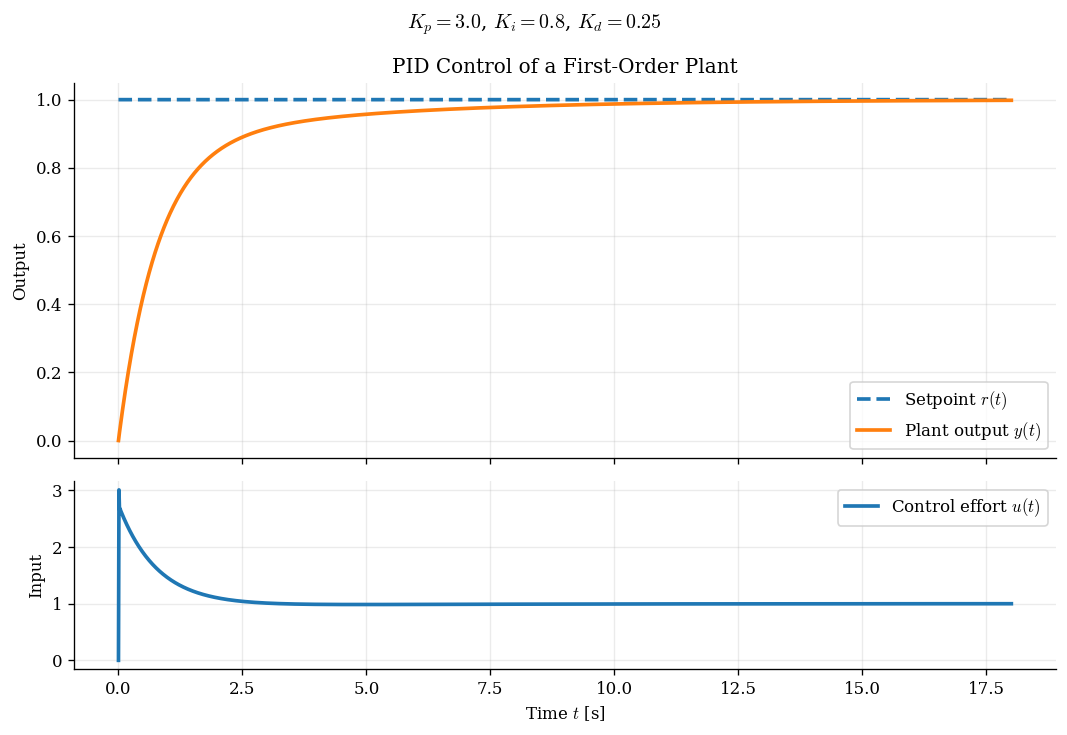

In [1]:
"""
PID Controller Response Plot Recipe

Author: Ziraddin Gulumjanli, 2026

This script visualizes a simple PID controller stabilizing a first-order plant.

Plant:
    dy/dt = (-y + K u) / tau

Controller:
    u(t) = K_p e(t) + K_i integral(e(t)) + K_d de(t)/dt

Where:
    e(t) = r(t) - y(t)

The goal is to show setpoint tracking, overshoot, and control effort.
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


@dataclass(frozen=True)
class PIDConfig:
    """Configuration for the PID simulation."""

    duration: float = 18.0
    dt: float = 0.01
    setpoint: float = 1.0
    plant_gain: float = 1.0
    plant_time_constant: float = 2.4
    kp: float = 3.0
    ki: float = 0.8
    kd: float = 0.25
    output_dir: Path = Path("figures")


def configure_matplotlib() -> None:
    """Apply publication-style Matplotlib settings."""

    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 600,
            "font.family": "serif",
            "mathtext.fontset": "cm",
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": True,
            "grid.alpha": 0.25,
            "lines.linewidth": 2.2,
        }
    )


def simulate_pid_response(config: PIDConfig) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Simulate a PID controller on a first-order plant."""

    time = np.arange(0.0, config.duration + config.dt, config.dt)
    setpoint = np.full(time.size, config.setpoint, dtype=float)
    output = np.zeros(time.size, dtype=float)
    control_effort = np.zeros(time.size, dtype=float)

    integral_error = 0.0
    previous_error = config.setpoint - output[0]

    for step_idx in range(1, time.size):
        error = setpoint[step_idx] - output[step_idx - 1]
        integral_error += error * config.dt
        derivative_error = (error - previous_error) / config.dt

        control_effort[step_idx] = (
            config.kp * error
            + config.ki * integral_error
            + config.kd * derivative_error
        )

        plant_derivative = (
            -output[step_idx - 1] + config.plant_gain * control_effort[step_idx]
        ) / config.plant_time_constant

        output[step_idx] = output[step_idx - 1] + config.dt * plant_derivative
        previous_error = error

    error = setpoint - output
    return time, setpoint, output, control_effort


def plot_pid_response(
    time: np.ndarray,
    setpoint: np.ndarray,
    output: np.ndarray,
    control_effort: np.ndarray,
    config: PIDConfig,
) -> plt.Figure:
    """Plot setpoint tracking and control effort."""

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(9.0, 6.2),
        sharex=True,
        gridspec_kw={"height_ratios": [2.0, 1.0]},
    )

    axes[0].plot(time, setpoint, linestyle="--", label=r"Setpoint $r(t)$")
    axes[0].plot(time, output, label=r"Plant output $y(t)$")
    axes[0].set_title("PID Control of a First-Order Plant")
    axes[0].set_ylabel("Output")
    axes[0].legend(frameon=True)

    axes[1].plot(time, control_effort, label=r"Control effort $u(t)$")
    axes[1].set_xlabel(r"Time $t$ [s]")
    axes[1].set_ylabel("Input")
    axes[1].legend(frameon=True)

    fig.suptitle(
        rf"$K_p={config.kp}$, $K_i={config.ki}$, $K_d={config.kd}$",
        y=0.98,
    )
    fig.tight_layout()

    return fig


def main() -> None:
    """Run the recipe and save the figure."""

    configure_matplotlib()

    config = PIDConfig()
    config.output_dir.mkdir(parents=True, exist_ok=True)

    time, setpoint, output, control_effort = simulate_pid_response(config)
    fig = plot_pid_response(
        time=time,
        setpoint=setpoint,
        output=output,
        control_effort=control_effort,
        config=config,
    )

    fig.savefig(config.output_dir / "control_pid_response.png", bbox_inches="tight")
    fig.savefig(config.output_dir / "control_pid_response.pdf", bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    main()
